# Drawdown risk measures

Drawdown-based risk measures describe how far the portfolio has fallen from its previous
high at each point in time. Where variance and CVaR look at the cross-sectional distribution
of single-period returns, drawdown measures look at the *path* of cumulative wealth — the
maximum loss you would have experienced by holding the portfolio from any peak to any
subsequent trough.

Four related measures are available:

| Measure | What it penalises |
| ------- | ----------------- |
| `MaximumDrawdown` | The single worst peak-to-trough decline over the whole period |
| `AverageDrawdown` | The time-average depth of the drawdown curve |
| `UlcerIndex` | The root-mean-square of the drawdown curve (penalises long shallow drawdowns more than `AverageDrawdown`) |
| `ConditionalDrawdownatRisk` | The expected drawdown conditional on being in the worst-α fraction (CDaR, the drawdown analogue of CVaR) |

> **When to reach for this**
>
> Reach for drawdown measures when the *recovery path* matters — trend-following strategies,
> strategies sold to retail investors who may redeem at the worst moment, or any portfolio
> where drawdown duration and depth are reported to stakeholders. Variance minimisation
> ignores paths entirely; these measures do not.

In [1]:
using PortfolioOptimisers, PrettyTables, DataFrames

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. Data and shared setup

In [2]:
using CSV, TimeSeries, Clarabel

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true))]

opt = JuMPOptimiser(; pe = pr, slv = slv)

JuMPOptimiser
       pe ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      slv ┼ 3-element Vector{Solver}
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
       wb ┼ WeightBounds
          │   lb ┼ Float64: 0.0
          │   ub ┴ Float64: 1.0
      bgt ┼ Float64: 1.0
     sbgt ┼ nothing
       lt ┼ nothing
       st ┼ nothing
     lcse ┼ nothing
      cte ┼ nothing
   gcarde ┼ nothing
  sgcarde ┼ nothing
     smtx ┼ nothing
    sgmtx ┼ nothing
      slt ┼ nothing
      sst ┼ nothing
     sglt ┼ nothing
     sgst ┼ nothing
       tn ┼ nothing
     fees ┼ nothing
     sets ┼ no

## 2. Minimising each drawdown measure

These measures drop into `MeanRisk` with no extra configuration. Their
constructors only take an optional `settings::RiskMeasureSettings`; `ConditionalDrawdownatRisk`
additionally accepts `alpha` (the tail probability, default 0.05).

In [3]:
r_mdd = MaximumDrawdown()
r_add = AverageDrawdown()
r_uci = UlcerIndex()
r_cdar = ConditionalDrawdownatRisk()

results = map([r_mdd, r_add, r_uci, r_cdar]) do r
    return optimise(MeanRisk(; r = r, opt = opt))
end
labels = ["MDD", "ADD", "Ulcer", "CDaR 5%"]

pretty_table(DataFrame(hcat(rd.nx, [r.w for r in results]...),
                       [:assets; Symbol.(labels)...]); formatters = [resfmt])

┌────────┬──────────┬──────────┬──────────┬──────────┐
│ assets │      MDD │      ADD │    Ulcer │  CDaR 5% │
│    Any │      Any │      Any │      Any │      Any │
├────────┼──────────┼──────────┼──────────┼──────────┤
│   AAPL │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    AMD │   -0.0 % │    0.0 % │    0.0 % │   -0.0 % │
│    BAC │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    BBY │   -0.0 % │    0.0 % │    0.0 % │   -0.0 % │
│    CVX │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│     GE │   -0.0 % │    0.0 % │    0.0 % │   -0.0 % │
│     HD │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    JNJ │ 67.181 % │ 19.758 % │ 29.674 % │ 38.725 % │
│    JPM │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│     KO │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    LLY │  6.369 % │    0.0 % │  4.612 % │  5.567 % │
│    MRK │  5.662 % │ 38.898 % │ 25.462 % │  7.176 % │
│   MSFT │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    PEP │ 10.952 % │    0.0 % │    0.0 % │    0.0 % │
│    PFE │

The allocations diverge noticeably.  `MaximumDrawdown` minimises the single worst event so
it concentrates into whatever reduces that peak loss.  `AverageDrawdown` and `UlcerIndex`
care about the whole recovery path and therefore spread weight more broadly.  `CDaR` is the
closest to CVaR in spirit and allocations.

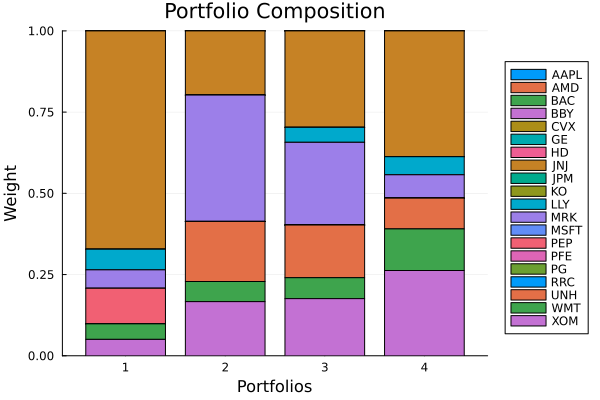

In [4]:
using StatsPlots, GraphRecipes, StatsBase
plot_stacked_bar_composition(results, rd)

To avoid an unreadable spaghetti chart, we compare drawdown paths with a heatmap instead
of many overlaid lines. Darker cells indicate deeper drawdowns for that optimiser at that
date.

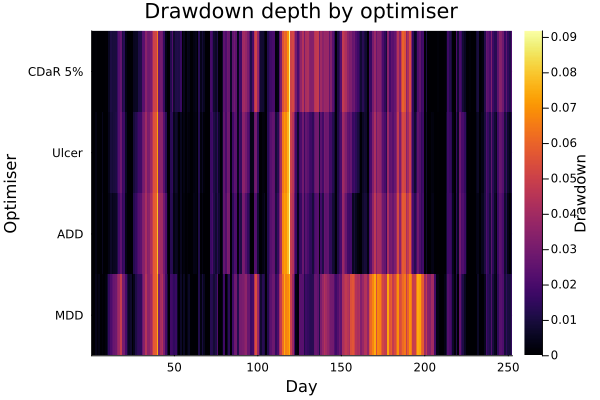

In [5]:
drawdown_grid = hcat([(-drawdowns(rd.X * res.w)) for res in results]...)
heatmap(eachindex(rd.ts), labels, drawdown_grid'; xlabel = "Day", ylabel = "Optimiser",
        colorbar_title = "Drawdown", title = "Drawdown depth by optimiser")

## 3. Tail level sensitivity for CDaR — sweeping alpha

`ConditionalDrawdownatRisk` accepts `alpha`. As `alpha → 0` it focuses on catastrophic
tail drawdowns; larger `alpha` broadens the tail set and moves toward average-tail behaviour.

In [6]:
alphas = [0.01, 0.05, 0.1, 0.25]
cdar_results = [optimise(MeanRisk(; r = ConditionalDrawdownatRisk(; alpha = a), opt = opt))
                for a in alphas]

pretty_table(DataFrame(hcat(rd.nx, [r.w for r in cdar_results]...),
                       [:assets; Symbol.("CDaR_" .* string.(alphas))...]);
             formatters = [resfmt])

┌────────┬───────────┬───────────┬──────────┬───────────┐
│ assets │ CDaR_0.01 │ CDaR_0.05 │ CDaR_0.1 │ CDaR_0.25 │
│    Any │       Any │       Any │      Any │       Any │
├────────┼───────────┼───────────┼──────────┼───────────┤
│   AAPL │     0.0 % │     0.0 % │    0.0 % │     0.0 % │
│    AMD │     0.0 % │    -0.0 % │   -0.0 % │    -0.0 % │
│    BAC │     0.0 % │     0.0 % │    0.0 % │     0.0 % │
│    BBY │     0.0 % │    -0.0 % │   -0.0 % │     0.0 % │
│    CVX │     0.0 % │     0.0 % │    0.0 % │     0.0 % │
│     GE │     0.0 % │    -0.0 % │   -0.0 % │    -0.0 % │
│     HD │     0.0 % │     0.0 % │    0.0 % │     0.0 % │
│    JNJ │  63.749 % │  38.725 % │ 34.907 % │  31.571 % │
│    JPM │     0.0 % │     0.0 % │    0.0 % │     0.0 % │
│     KO │   1.179 % │     0.0 % │    0.0 % │     0.0 % │
│    LLY │   8.586 % │   5.567 % │  3.354 % │   5.208 % │
│    MRK │     0.0 % │   7.176 % │ 15.667 % │   22.41 % │
│   MSFT │     0.0 % │     0.0 % │    0.0 % │     0.0 % │
│    PEP │    

Lower alpha focuses more on preventing catastrophic drawdowns; higher alpha cares about
average drawdown depth across more of the distribution.

## 4. Constraining drawdown rather than minimising it

Instead of using a drawdown measure as the primary objective, you can impose an **upper
bound** on it while optimising return. Here we find the portfolio that maximises
risk-adjusted return subject to a CDaR ceiling, using `RiskMeasureSettings` to
set the `ub`.

In [7]:
rf = 4.2 / 100 / 252
r_cdar_ub = ConditionalDrawdownatRisk(; settings = RiskMeasureSettings(; ub = 0.08))
res_cdar_max_ratio = optimise(MeanRisk(; r = r_cdar_ub, obj = MaximumRatio(; rf = rf),
                                       opt = opt))
println("CDaR-constrained max-ratio retcode: $(res_cdar_max_ratio.retcode)")

CDaR-constrained max-ratio retcode: OptimisationSuccess
  res ┴ Dict{Any, Any}: Dict{Any, Any}()



## 5. Drawdown analytics — post-optimisation diagnostics

After choosing a portfolio, `drawdowns()` and `cumulative_returns()` give a full picture of
how the portfolio would have behaved over the in-sample period.  These are analytics, not
objectives — use them to *understand* a portfolio after the optimiser has run.

In [8]:
# Pick two portfolios to compare side by side.
w_var = optimise(MeanRisk(; r = Variance(), opt = opt)).w
w_cdar = results[4].w   ## CDaR minimising portfolio

# Portfolio return time series for each weight vector.
ret_var = rd.X * w_var
ret_cdar = rd.X * w_cdar

# Cumulative returns (simple).
cr_var = cumulative_returns(ret_var)
cr_cdar = cumulative_returns(ret_cdar)

# Drawdown series.
dd_var = drawdowns(ret_var)
dd_cdar = drawdowns(ret_cdar)

# Summary statistics.
pretty_table(DataFrame(;
                       :Metric =>
                           ["Max drawdown", "Avg drawdown", "Ulcer index", "CDaR 5%"],
                       :MinVariance =>
                           [-minimum(dd_var), -mean(dd_var), sqrt(mean(dd_var .^ 2)),
                            -quantile(-dd_var, 0.95)],
                       :MinCDaR =>
                           [-minimum(dd_cdar), -mean(dd_cdar), sqrt(mean(dd_cdar .^ 2)),
                            -quantile(-dd_cdar, 0.95)]); formatters = [resfmt])

┌──────────────┬─────────────┬──────────┐
│       Metric │ MinVariance │  MinCDaR │
│       String │     Float64 │  Float64 │
├──────────────┼─────────────┼──────────┤
│ Max drawdown │      9.19 % │  8.965 % │
│ Avg drawdown │     2.622 % │  1.902 % │
│  Ulcer index │     3.472 % │  2.535 % │
│      CDaR 5% │    -6.869 % │ -5.095 % │
└──────────────┴─────────────┴──────────┘


The CDaR-minimising portfolio has a materially lower CDaR than the variance-minimising
portfolio. The variance portfolio may still have a lower standard deviation, but when you
look at the path, its drawdown profile is worse in the tail.

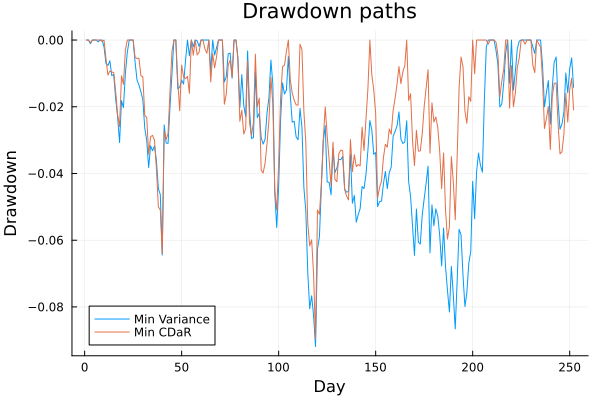

In [9]:
plot(cr_var; label = "Min Variance", xlabel = "Day", ylabel = "Cumulative return",
     title = "Cumulative return paths")
plot!(cr_cdar; label = "Min CDaR")

plot(dd_var; label = "Min Variance", xlabel = "Day", ylabel = "Drawdown",
     title = "Drawdown paths")
plot!(dd_cdar; label = "Min CDaR")

## Summary

Drawdown measures target the *path* of cumulative wealth:

  - `MaximumDrawdown` guards against the worst single episode but can produce
    concentrated portfolios.
  - `AverageDrawdown` and `UlcerIndex` penalise the entire recovery curve.
  - `ConditionalDrawdownatRisk` is the natural drawdown analogue of CVaR and
    responds to `alpha` the same way.
    - Heatmaps of `drawdowns()` are often clearer than overlaid line plots when comparing many
        drawdown-optimised portfolios.
  - After optimisation, `drawdowns()` and `cumulative_returns()` give the full diagnostic
    picture for any weight vector without re-running the optimiser.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*